# Dataset description
## Hectares of coca cultivation over the years

**Source**: Ministerio de Justicia y del derecho

**Download**: [Datos Abiertos](https://www.datos.gov.co/Justicia-y-Derecho/Detecci-n-de-Cultivos-de-Coca-hect-reas-/acs4-3wgp/about_data)

# Code
## Imports

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [7]:
path = "./data/Detección_de_Cultivos_de_Coca_(hectáreas)_20260804.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [8]:
df.drop(columns=["CODDEPTO", "CODMPIO", "MUNICIPIO"], inplace=True)

df["2020"] = df["2020"].str.replace(",", "").astype(float)
tot_dep = df.groupby("DEPARTAMENTO").sum()
tot_dep.loc["TOTAL"] = tot_dep.sum(axis=0, numeric_only=True)

tot_nat = tot_dep.loc["TOTAL", :]

biggest = tot_dep.nlargest(columns="2024", n=6)["2024"]

## Plot

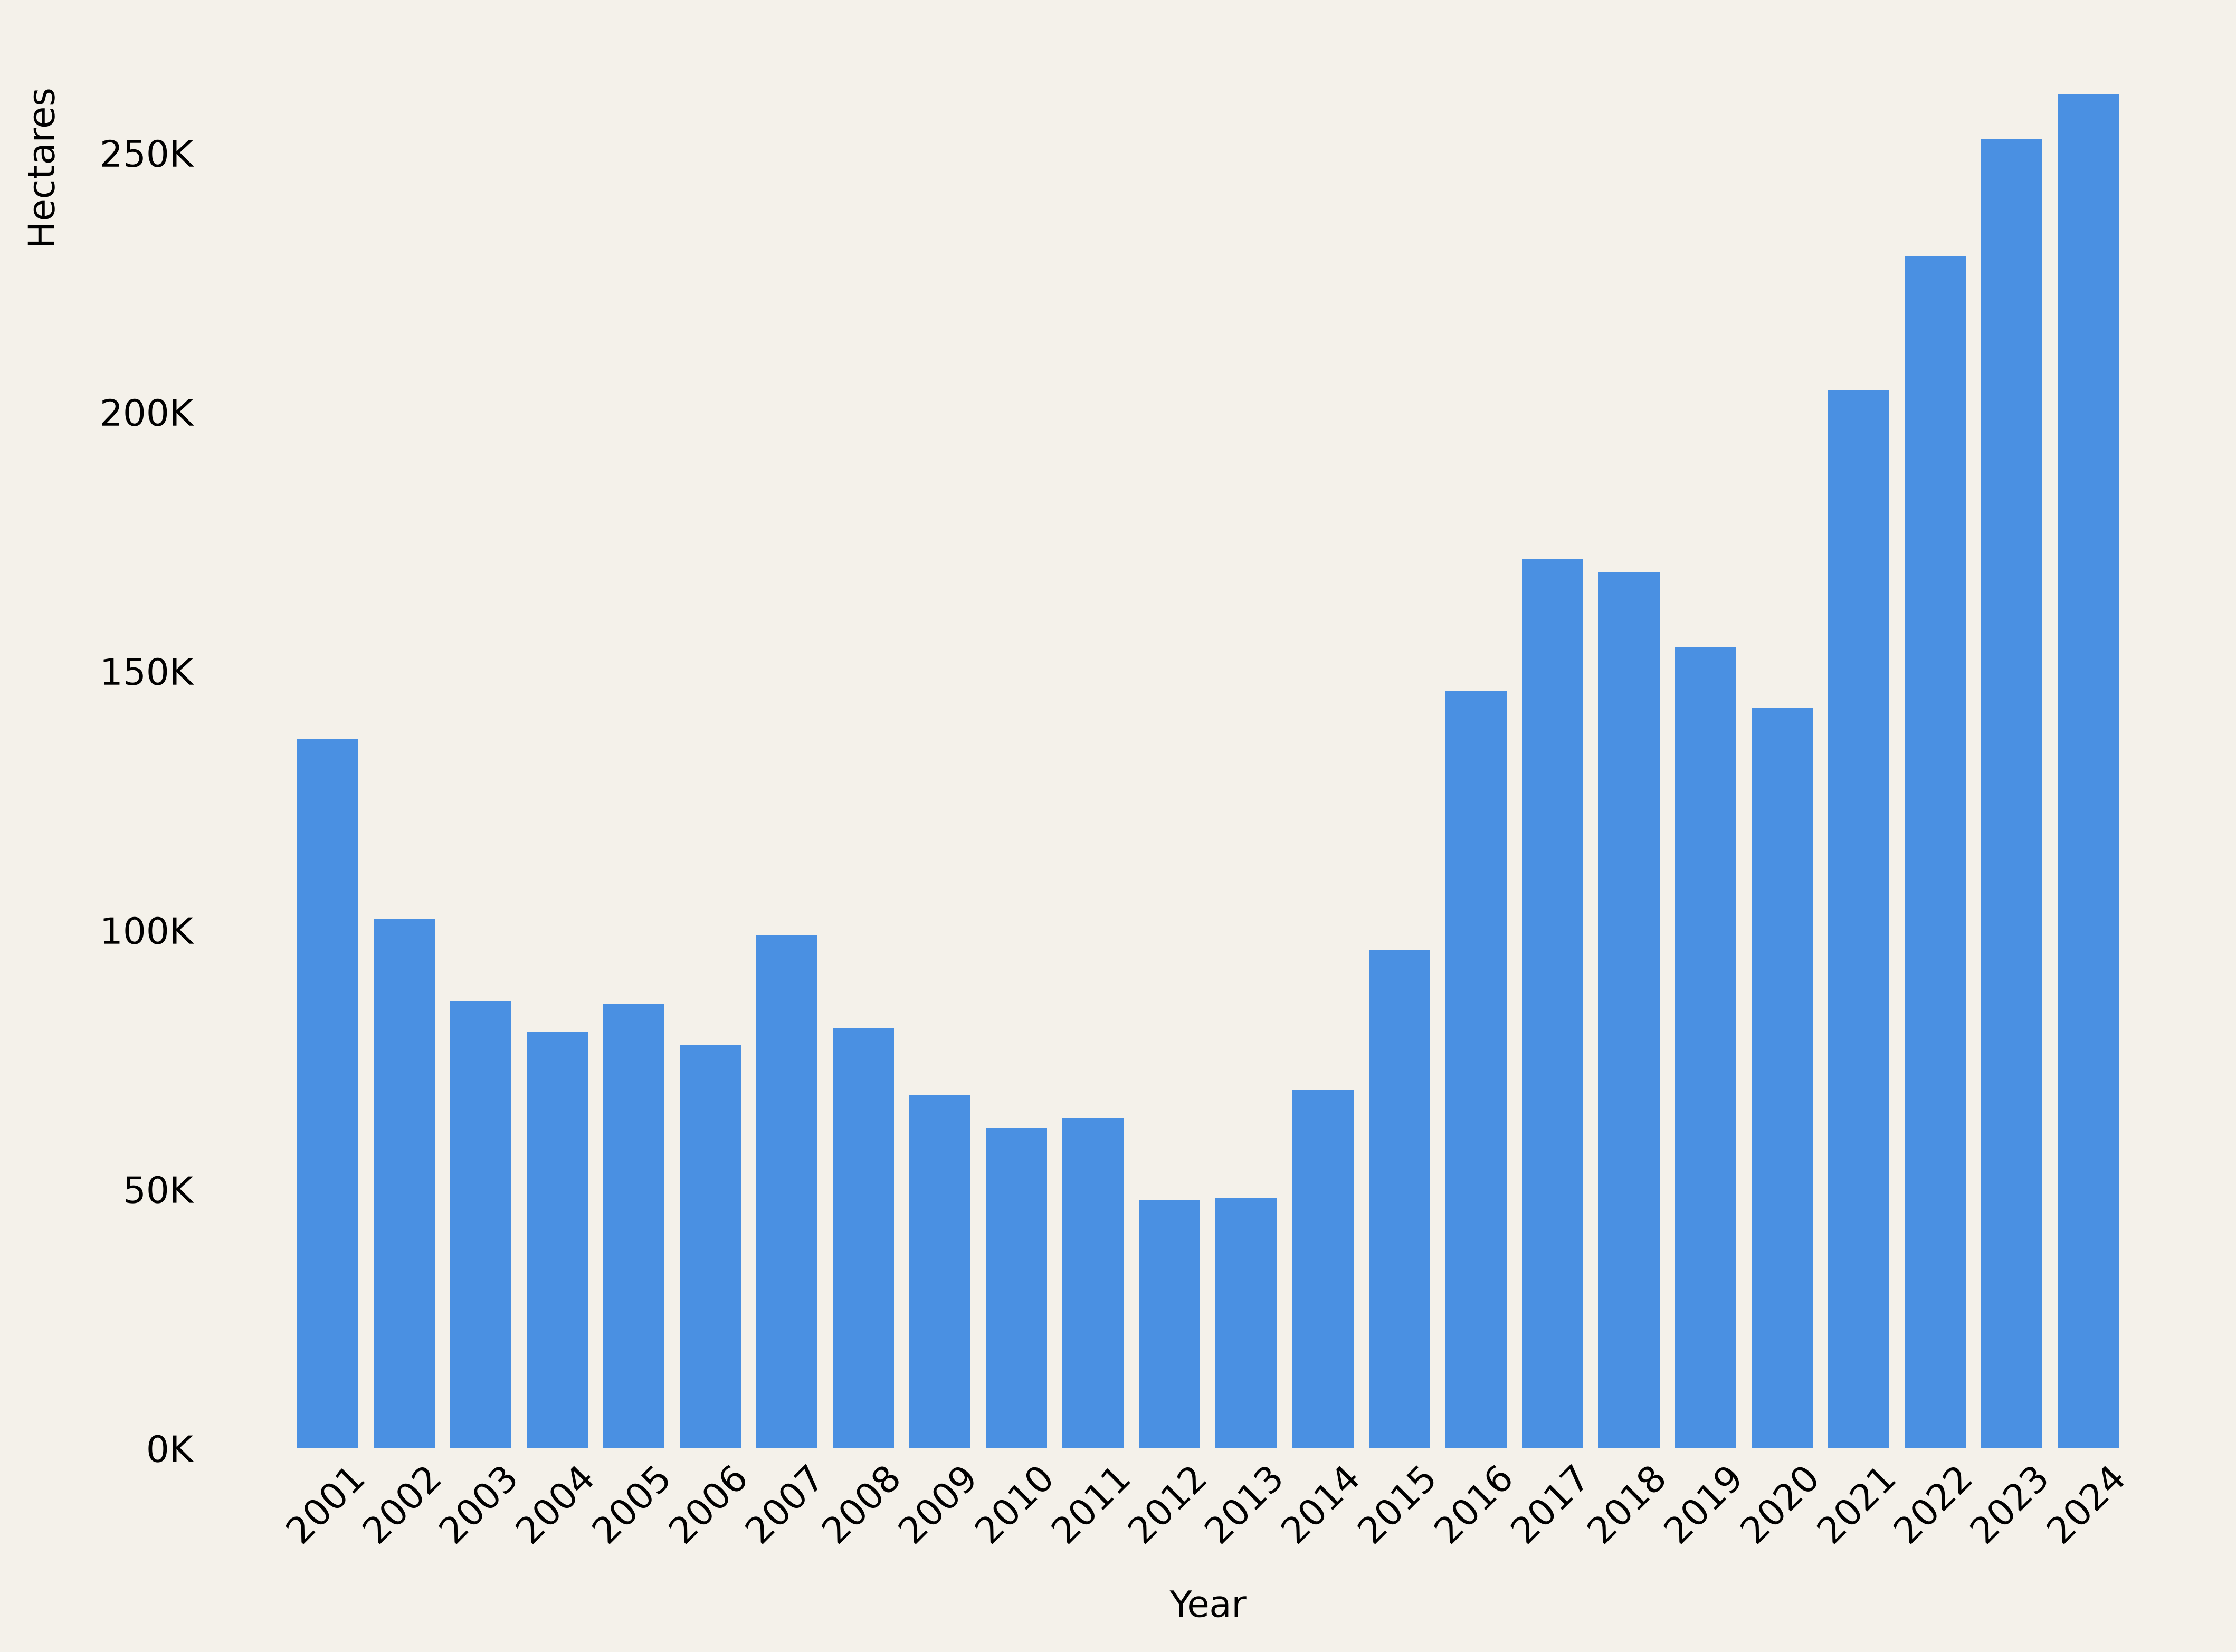

In [9]:
blue = "#4a90e2"
background = "#F4F1EA"

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.bar(tot_nat.index, tot_nat.values, color=blue)

plt.xticks(tot_nat.index, rotation=45)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

plt.ylabel("Hectares", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()